# 01 - Data quality and exploratory analysis
FreshBasket loyalty workbook: member profiles, 18 months of monthly activity (Jan 2023 - Jun 2024) and the churn
label (no purchase in Apr-Jun 2024 despite earlier purchases). Code: `src/churn/data_validation.py`,
`src/churn/preprocessing.py`, `src/churn/eda.py`.

> **At a glance**
> * 2,608 profile rows, 28,073 activity rows, 2,605 label rows for 2,600 members; all three tables join on `CUSTOMER_ID`.
> * Spend errors could be repaired exactly, because `TOTAL_SPEND = TRANSACTIONS x AVG_BASKET_VALUE` on 99.8% of
>   purchase months.
> * Three label-table columns are computed over the label window and would leak the answer; they are never used.
> * **80% of the Apr-Jun 2024 churners had already stopped buying before the label window.** Among members still
>   buying, churn is a steady ~10% per quarter. That reframes the whole problem.

In [1]:
%matplotlib inline
from churn.notebook import *   # pandas as pd, numpy as np, display, Markdown, fig(), tab(), run_step(), paths P

## 1. What was supplied (before any cleaning)

In [2]:
display(tab("table_summary"))
tab("integrity_checks")

,table,rows,columns,exact_duplicate_rows,candidate_key,duplicate_keys,date_column,date_min,date_max,unique_customers
0,fb Customer Profile,2608,10,8,CUSTOMER_ID,8,SIGNUP_DATE,2021-02-18,2024-05-02,2600
1,fb Monthly Activity,28073,12,58,CUSTOMER_ID + MONTH,60,MONTH,2023-01-01,2024-06-01,2594
2,fb Churn Label,2605,6,5,CUSTOMER_ID,5,NaN,NaN,NaN,2600


,check,passed,evidence
0,activity customers exist in the profile table,True,0 orphan IDs
1,label customers == profile customers,True,"label-only 0, profile-only 0"
2,every labelled customer has activity rows,False,6 members without any activity row
3,CUSTOMER_ID unique in profile,False,8 repeated IDs (8 exact duplicate rows)
4,CUSTOMER_ID unique in label table,False,5 repeated IDs (5 exact duplicate rows)
5,CUSTOMER_ID + MONTH unique in activity,False,60 repeated keys (58 exact duplicate rows)
6,18 consecutive activity months,True,"2023-01-01 to 2024-06-01, 18 distinct months"
7,every member has an activity row in all 18 months,False,"400 of 2594 members; rows per member median 11, min 1 (late sign-ups, lapsed members and deleted rows)"
8,join grain: profile 1 : label 1 : activity many (after de-duplication),True,profile and label are one row per member once exact duplicates are removed; activity is one row per member-month
9,label CHURNED is binary,True,"values [0, 1], churn rate 31.5%"


The three tables share `CUSTOMER_ID` and contain exactly the same 2,600 members. Profile and label are one row
per member once exact duplicates are dropped; activity is one row per member-month. Six members have no activity at
all, and only 400 members have a row in every month (late sign-ups, lapsed members and deleted rows). So the
modelling dataset is built at **member x snapshot** grain rather than with a raw merge, which would repeat member
attributes once per month.

## 2. Data-quality findings (every treatment is logged, nothing is cleaned silently)

In [3]:
tab("data_quality_findings")

,table,issue,evidence,severity,treatment,reason
0,fb Churn Label,Post-outcome columns in the label table,"LAST_PURCHASE_DATE, MONTHS_OBSERVED, INSUFFICIENT_HISTORY_FLAG are computed over the whole window including Apr-Jun ...",High,Never used as features; honest equivalents are recomputed from activity up to each cutoff,Direct target leakage
1,fb Customer Profile,Inconsistent casing/whitespace in CITY,"40 raw spellings -> 10 values (Austin, Boise, Columbus, Denver, Madison, Nashville, Portland, Raleigh, Spokane, Tulsa)",Medium,Trimmed and title-cased,"Variants such as 'PORTLAND', ' Portland ' and 'portland' are one value; left as-is they split segments"
2,fb Customer Profile,Inconsistent casing/whitespace in MEMBERSHIP_TIER,"12 raw spellings -> 3 values (Gold, Platinum, Silver)",Medium,Trimmed and title-cased,"Variants such as 'PORTLAND', ' Portland ' and 'portland' are one value; left as-is they split segments"
3,fb Customer Profile,Members who joined during the label window,51 members signed up after 2024-03-31,Medium,Not eligible for the official snapshot (no history before the label window),Churn is only defined for members with earlier purchase history
4,fb Monthly Activity,Duplicate activity rows,"58 exact duplicates; 2 customer-months with two different rows, each pair differing only in the sign of TOTAL_SPEND",Medium,Exact duplicates dropped; for conflicting pairs the positive-spend row is kept,The pairs are the same record entered twice with a sign error
5,fb Monthly Activity,Negative spend,22 rows; |spend| equals transactions x avg basket in 100% of them,Medium,Sign flipped (absolute value),Pure sign-entry errors
6,fb Monthly Activity,Outlier spend values,"13 rows where spend is > 2x transactions x avg basket (e.g. 3,731 vs 297); 99.9th percentile of spend otherwise 634",Medium,Replaced by transactions x average basket,"Both transaction count and basket value are normal in these rows, so only the total was mistyped"
7,fb Monthly Activity,Missing months inside members' activity spans,953 customer-months missing between existing rows for 769 members (3.3% of those spans),Medium,Treated as unknown: features use observed months only and count the gaps. For each snapshot a gap is recognised from...,"Deleted records, not inactivity: members have rows on both sides"
8,fb Churn Label,Label reconstruction check,"rebuilding CHURNED from activity (no purchase Apr-Jun 2024, purchases before) agrees for 99.65% of members; the 9 di...",Medium,"The given CHURNED is the target for the official snapshot; rebuilt labels are used only for earlier snapshots, accep...",Confirms the definition and shows the label table was built before rows were deleted
9,fb Customer Profile,Duplicate profile rows,"8 exact duplicate rows (8 repeated IDs, all identical)",Low,Dropped,Identical copies carry no information


The brief lists the issues to look for (missing months, duplicates, invalid/negative spend, zero-transaction
anomalies, inconsistent casing, outlier spend). All of them are present. The most useful discovery is the spend
identity: spend equals transactions x average basket on 99.8% of purchase months. That made it possible to **diagnose**
each spend error rather than guess:
* the 22 negative spends are pure sign errors (their absolute value matches the identity);
* the 13 extreme values are mistyped totals (e.g. 3,731 where the identity gives 297), not big shoppers.

The label table's `LAST_PURCHASE_DATE`, `MONTHS_OBSERVED` and `INSUFFICIENT_HISTORY_FLAG` are computed over the label
window (a last purchase before April implies churn), so they are excluded. Rebuilding `CHURNED` from the activity with
the brief's definition agrees for 99.65% of members; all 9 disagreements are members whose activity row for their
last-purchase month was deleted.

## 3. Who churns? Two very different populations

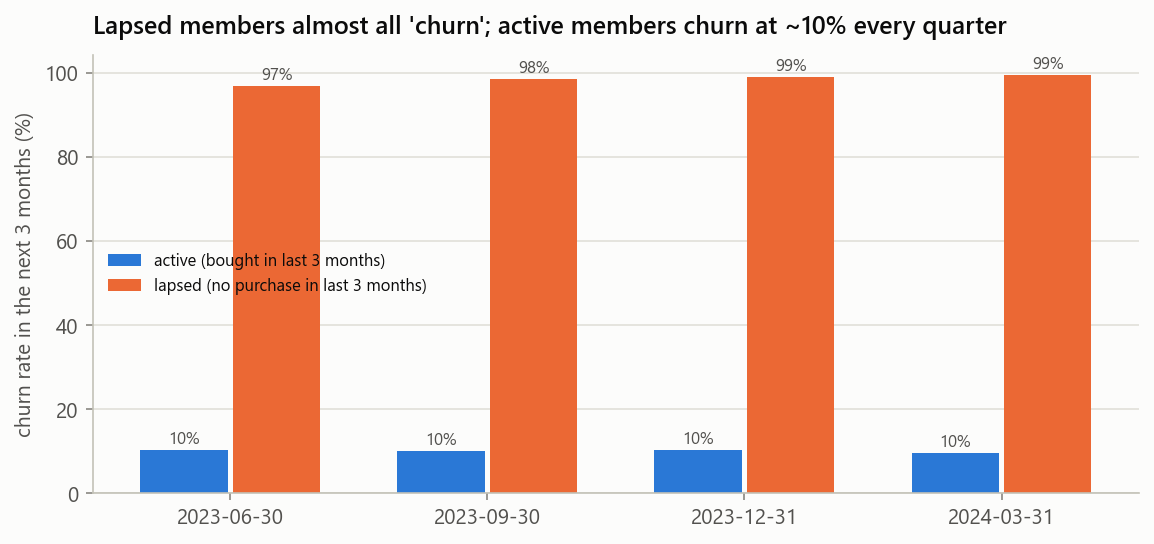

,cutoff,label_window,eligible_members,churn_rate_all,active_members,churn_rate_active,lapsed_members,churn_rate_lapsed,role
0,2023-06-30,Jul 2023 +3 months,1787,0.181869,1624,0.102833,163,0.969325,training (label rebuilt)
1,2023-09-30,Oct 2023 +3 months,1980,0.245455,1655,0.100302,325,0.984615,training (label rebuilt)
2,2023-12-31,Jan 2024 +3 months,2167,0.301338,1681,0.102320,486,0.989712,training (label rebuilt)
3,2024-03-31,Apr 2024 +3 months,2368,0.343328,1715,0.095627,653,0.993874,test (given CHURNED)
4,2024-06-30,Jul 2024 +3 months,2474,NaN,1657,NaN,817,NaN,scoring (future unknown)


In [4]:
fig("eda_churn_by_population", 750)
tab("snapshots_target_distribution")

**What does this show?** Churn rate in the 3 months after each quarterly cutoff, split by whether the member bought anything in the 3 months before the cutoff.

**Why is it relevant?** The brief's label counts every member who stops buying, including members who stopped long ago.

**What did we learn?** Members who were already lapsed 'churn' at 97-99% in every quarter. Members still buying churn at 9.6-10.3%, every quarter. The headline churn rate rises (18% -> 34%) only because lapsed members accumulate.

**What does it imply?** Predicting the lapsed group is trivial and too late for a retention offer. The real early-warning problem is the active members, so every result is reported for both populations.

## 4. Does churn differ by tier, city or signup cohort?

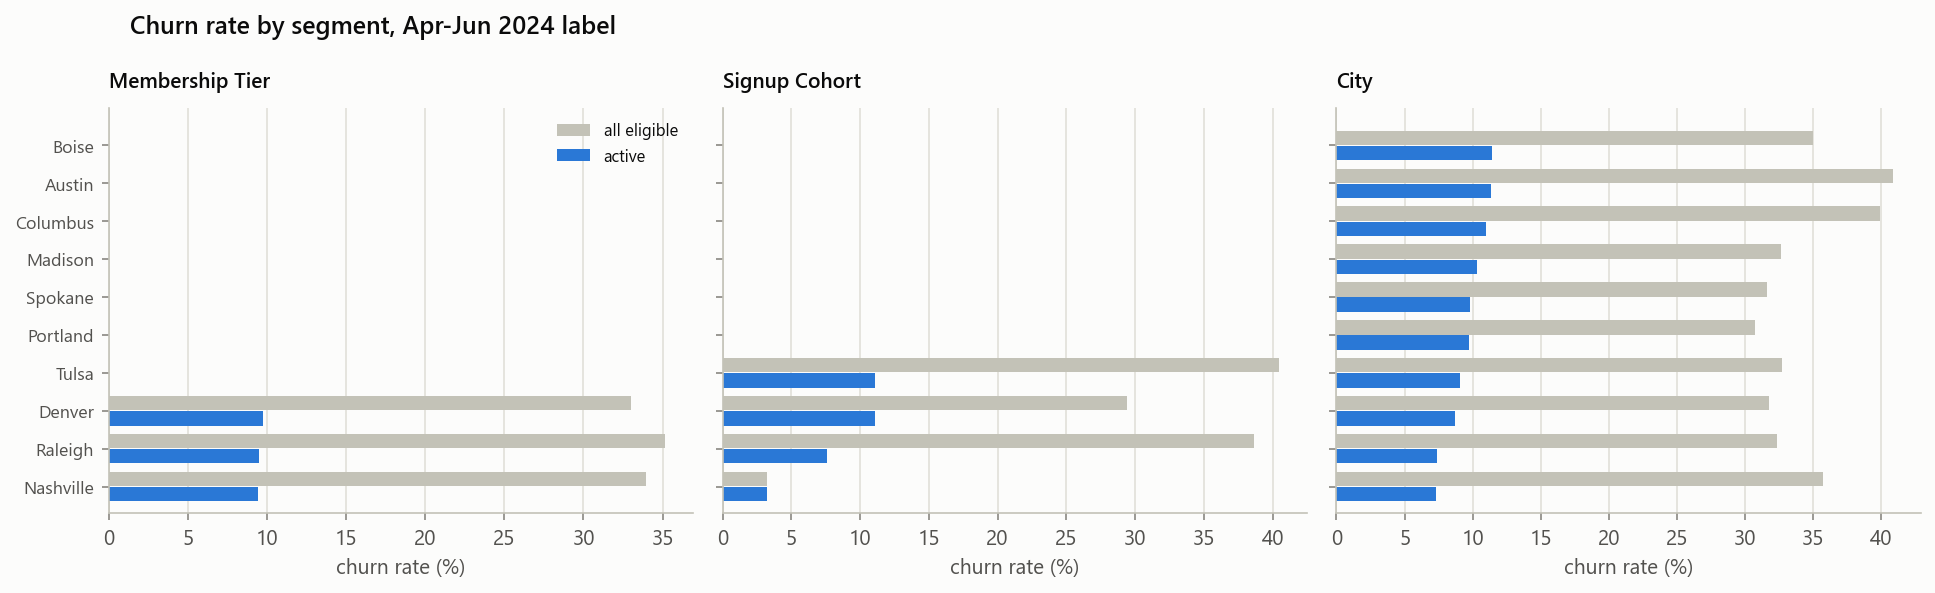

,attribute,value,population,churn_rate,n
21,CITY,Nashville,active,0.0728,151.0
23,CITY,Raleigh,active,0.0737,190.0
19,CITY,Denver,active,0.0867,173.0
25,CITY,Tulsa,active,0.0905,199.0
22,CITY,Portland,active,0.0970,165.0
24,CITY,Spokane,active,0.0983,173.0
20,CITY,Madison,active,0.1029,175.0
18,CITY,Columbus,active,0.1098,164.0
16,CITY,Austin,active,0.1132,159.0
17,CITY,Boise,active,0.1145,166.0


In [5]:
fig("eda_segment_rates", 1000)
s = tab("eda_segment_rates"); s[s.population == "active"].sort_values(["attribute", "churn_rate"])

**What does this show?** Apr-Jun 2024 churn rate by membership tier, signup cohort and city, for all eligible and for active members.

**Why is it relevant?** The brief asks whether tier and other segments affect churn risk, and the business currently segments by tier.

**What did we learn?** Among active members tier makes almost no difference (Silver 9.5%, Gold 9.8%, Platinum 9.4%). Cities range 7.3-11.4% on 150-200 members each (small differences). Members who joined in 2024 churn least (3.2%).

**What does it imply?** Tier-based retention budgets are not supported by the data; behaviour has to do the targeting.

## 5. Engagement, support and purchase trend vs churn (active members)

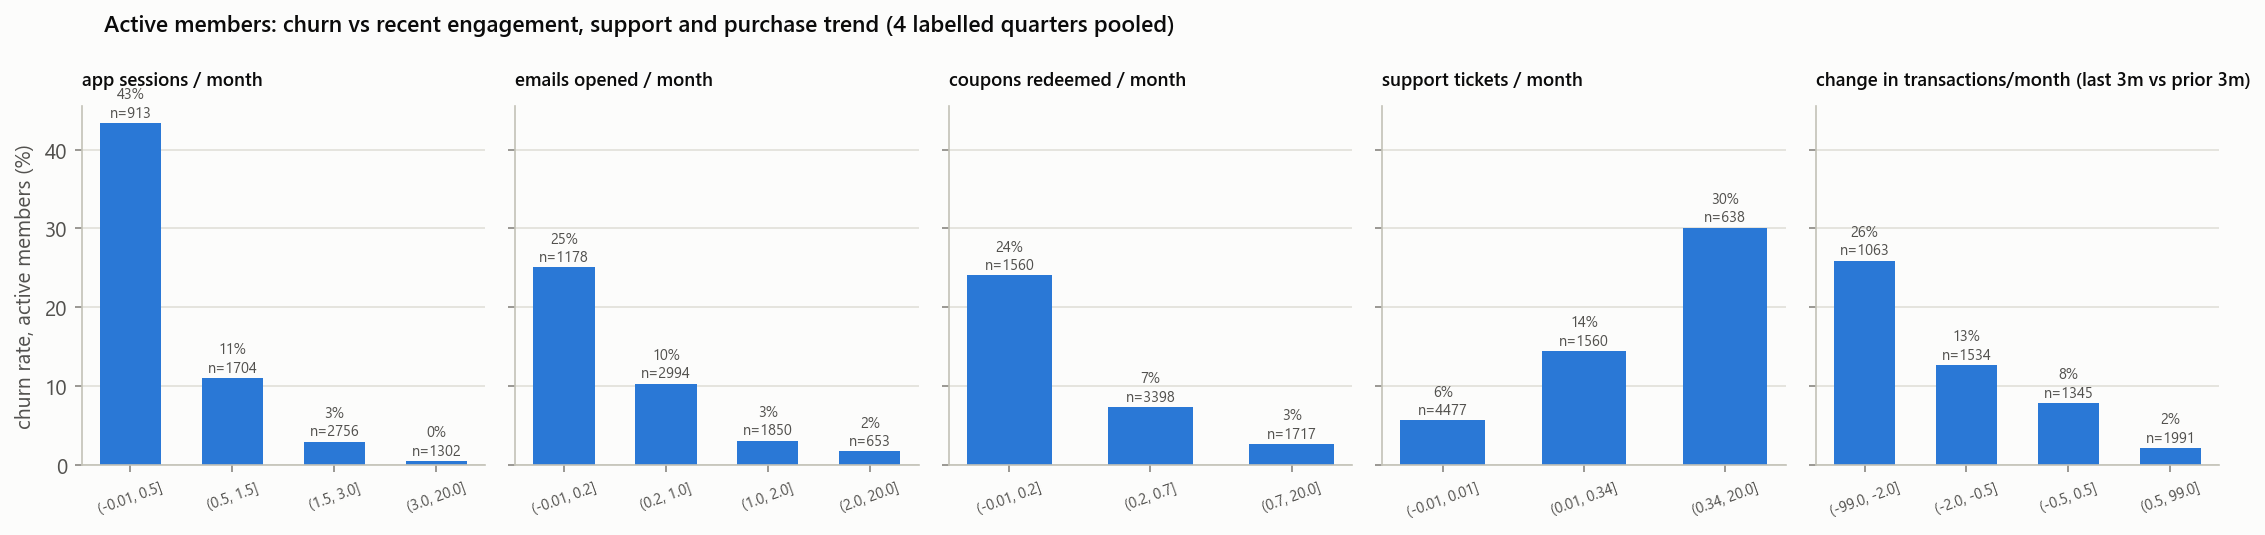

,feature,bin,churn_rate,n
0,app_avg_3m,"(-0.01, 0.5]",0.4337,913.0
1,app_avg_3m,"(0.5, 1.5]",0.1097,1704.0
2,app_avg_3m,"(1.5, 3.0]",0.0290,2756.0
3,app_avg_3m,"(3.0, 20.0]",0.0046,1302.0
4,email_avg_3m,"(-0.01, 0.2]",0.2504,1178.0
5,email_avg_3m,"(0.2, 1.0]",0.1025,2994.0
6,email_avg_3m,"(1.0, 2.0]",0.0303,1850.0
7,email_avg_3m,"(2.0, 20.0]",0.0168,653.0
8,coupons_avg_3m,"(-0.01, 0.2]",0.2404,1560.0
9,coupons_avg_3m,"(0.2, 0.7]",0.0733,3398.0


In [6]:
fig("eda_engagement_support", 1100)
tab("eda_engagement_support")

**What does this show?** Churn rate of active members by their last-3-month app sessions, emails opened, coupons redeemed, support tickets and change in transactions (4 labelled quarters pooled).

**Why is it relevant?** The brief asks for the observed relationship between engagement, support experience and churn.

**What did we learn?** Strong gradients: 43% churn with <= 0.5 app sessions a month vs 0.5% above 3; 30% churn with more than one ticket every three months vs 5.6% with none; 26% churn when transactions fall by more than 2 a month.

**What does it imply?** Engagement, support and purchase-trend features should carry the signal. These are associations: engaged members may simply be the ones who were going to stay.

## 6. Do churners fade before they leave?

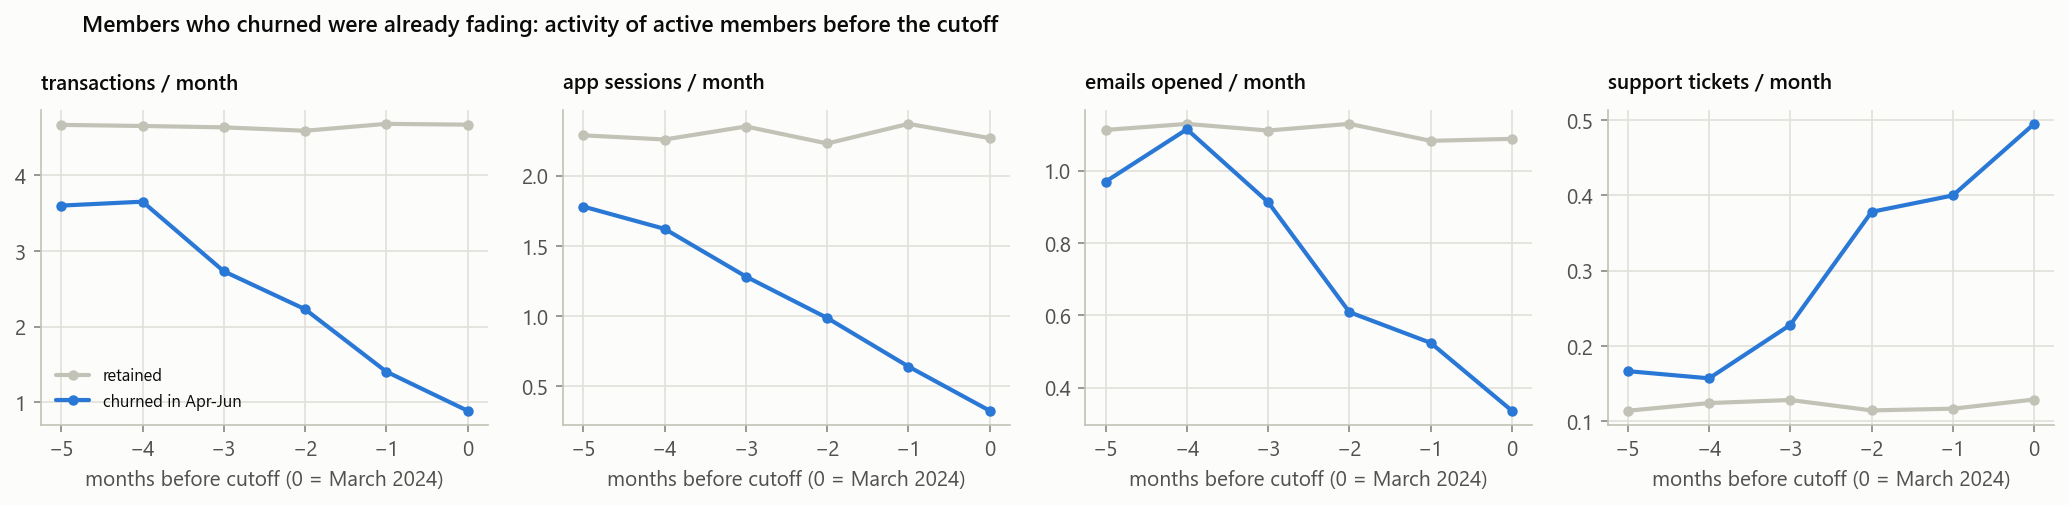

,churn,m_before,TRANSACTIONS,APP_SESSIONS,EMAILS_OPENED,SUPPORT_TICKETS
0,0.0,0,4.666,2.268,1.088,0.129
1,0.0,1,4.677,2.369,1.082,0.117
2,0.0,2,4.586,2.230,1.129,0.115
3,0.0,3,4.631,2.351,1.111,0.128
4,0.0,4,4.649,2.258,1.129,0.124
5,0.0,5,4.663,2.288,1.112,0.114
6,1.0,0,0.891,0.327,0.337,0.495
7,1.0,1,1.407,0.641,0.524,0.400
8,1.0,2,2.231,0.987,0.609,0.378
9,1.0,3,2.732,1.282,0.913,0.228


In [7]:
fig("eda_trajectories", 1100)
tab("eda_trajectories")

**What does this show?** Average monthly activity of members active at the March 2024 cutoff, in the 6 months before it, split by whether they churned in Apr-Jun.

**Why is it relevant?** If churn builds up gradually, a model using only pre-cutoff data can see it coming.

**What did we learn?** Churners fade for months: transactions 3.6 -> 0.9 a month, app sessions 1.8 -> 0.3, emails 1.0 -> 0.3, while support tickets rise 0.17 -> about 0.5. Retained members stay flat (about 4.7 transactions a month).

**What does it imply?** There is a window to act before the last purchase, and trend features (last 3 months vs the 3 before) should help.

## Takeaways for modelling
* Build features only from months up to the cutoff; exclude the label-window columns.
* Report lapsed and active members separately; the active members are the retention problem.
* Recency, purchase trend, app/email engagement and support tickets are the signals to model; demographics and tier
  look weak.